# 05 — ML Pipeline
## Two-Stage Feature Selection + Model Training + Evaluation (Drebin v1)

**Pipeline 5 bước:**
1. Load dữ liệu Drebin v1 (215 features, ~15K mẫu, binary: Benign/Malware)
2. Tiền xử lý: LabelEncoder → pd.to_numeric (xử lý '?') → MinMaxScaler
3. **Two-Stage Feature Selection** — Stage 1: Chi-square SelectKBest (Relevance) + Stage 2: Pearson Correlation Filter (Redundancy)
4. Train: RF / SVM / KNN / NB / MLP / XGBoost
5. Đánh giá: Stratified 5-Fold CV — Accuracy / Precision / Recall / F1 / MCC / ROC-AUC

> **Nhất quán với MalDroid2020 (`02_pipeline.ipynb`):**  
> Cùng phương pháp Two-Stage Chi²+Correlation cho cả 2 bộ dữ liệu.  
> Drebin (215 features) → range k nhỏ hơn: [20, 30, 50, 80, 100, 150, 200].  
> MalDroid2020 (50K features) → range k lớn hơn: [50, 100, 200, 500, 1000, 2000, 3000].

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import pickle
import time
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, matthews_corrcoef, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

BASE_DIR     = Path(r'H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020')
DREBIN_CSV   = BASE_DIR / 'csv' / 'drebin' / 'Drebin_v1.csv'
OUT_DIR      = BASE_DIR / 'notebooks' / 'artifacts' / 'drebin'
FIG_DIR      = BASE_DIR / 'notebooks' / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL = 'class'
print('Paths OK')
print(f'Artifacts -> {OUT_DIR}')

Paths OK
Artifacts -> H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\notebooks\artifacts\drebin


## 2. Load & Tiền xử lý

In [2]:
# Load dữ liệu
df = pd.read_csv(DREBIN_CSV)
print(f'[1] Loaded: {df.shape}')
print(f'    Labels: {dict(df[LABEL_COL].value_counts())}')

# Tách X, y
X_raw = df.drop(columns=[LABEL_COL])
y_raw = df[LABEL_COL]

# Label encoding: B -> 0, S -> 1
le = LabelEncoder()
y = le.fit_transform(y_raw.astype(str))
feature_names = list(X_raw.columns)
print(f'[2] Label classes: {list(le.classes_)} -> {list(range(len(le.classes_)))}')

# Xu ly gia tri '?' va NaN: ep kieu numeric, fill = 0
q_count = (X_raw == '?').sum().sum() if X_raw.dtypes.eq('object').any() else 0
X_raw = X_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f'[3] Gia tri "?": {q_count} o da doi thanh 0')
X_np = X_raw.values.astype(float)

# MinMax scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(X_np)
print(f'[4] MinMax scaled: X.shape = {X.shape}, range [{X.min():.2f}, {X.max():.2f}]')

[1] Loaded: (15036, 216)
    Labels: {'B': np.int64(9476), 'S': np.int64(5560)}
[2] Label classes: ['B', 'S'] -> [0, 1]
[3] Gia tri "?": 5 o da doi thanh 0
[4] MinMax scaled: X.shape = (15036, 215), range [0.00, 1.00]


## 3. Two-Stage Feature Selection

Phương pháp lọc hai bước — **nhất quán với MalDroid2020** (`02_pipeline.ipynb`):

**Stage 1 — Relevance (Chi-square):**
Dùng `SelectKBest(chi2)` để chọn top-k features có mối liên hệ thống kê cao nhất với nhãn lớp.
Dựa trên phân phối χ² giữa từng feature và biến mục tiêu.

**Stage 2 — Redundancy (Pearson Correlation Filter):**
Trong số k features từ Stage 1, loại bỏ các features có Pearson correlation |r| > 0.95 với bất kỳ feature nào đã chọn trước.

**Elbow Analysis:**
Vẽ đường cong k vs F1 với range k = [20, 30, 50, 80, 100, 150, 200]
(Drebin có 215 features nên range nhỏ hơn MalDroid2020 — hoàn toàn tự nhiên)
để xác định điểm 'elbow' tối ưu (thêm feature không cải thiện đáng kể).

In [3]:
def two_stage_feature_selection(
    X, y, feature_names,
    k_stage1=100, corr_threshold=0.95,
):
    n_features = X.shape[1]
    k_actual = min(k_stage1, n_features)

    # Stage 1: Chi-square SelectKBest
    selector = SelectKBest(chi2, k=k_actual)
    selector.fit(X, y)
    chi2_scores_all  = selector.scores_
    chi2_pvalues_all = selector.pvalues_
    stage1_mask  = selector.get_support()
    stage1_idx   = np.where(stage1_mask)[0]   # global indices
    stage1_names = [feature_names[i] for i in stage1_idx]
    print(f'[Stage 1] Chi2 SelectKBest: {len(stage1_idx)} features (k={k_actual})')

    # Stage 2: Pearson Correlation Filter
    X_stage1 = X[:, stage1_idx]
    corr_matrix = np.corrcoef(X_stage1.T)
    keep_local = []
    for i in range(len(stage1_idx)):
        redundant = False
        for j in keep_local:
            if abs(corr_matrix[i, j]) > corr_threshold:
                redundant = True
                break
        if not redundant:
            keep_local.append(i)

    final_global_indices = [stage1_idx[i] for i in keep_local]
    final_names = [feature_names[i] for i in final_global_indices]
    print(f'[Stage 2] Correlation filter (|r|>{corr_threshold}): {len(final_global_indices)} features')
    return final_global_indices, final_names, chi2_scores_all, chi2_pvalues_all

print('two_stage_feature_selection() defined.')

two_stage_feature_selection() defined.


Elbow Analysis — k vs F1 (3-fold CV, RF fast):
  k=  20  F1=0.8665
  k=  30  F1=0.9492
  k=  50  F1=0.9551
  k=  80  F1=0.9677
  k= 100  F1=0.9667
  k= 150  F1=0.9697
  k= 200  F1=0.9702

Peak F1 = 0.9702 | Elbow k = 80


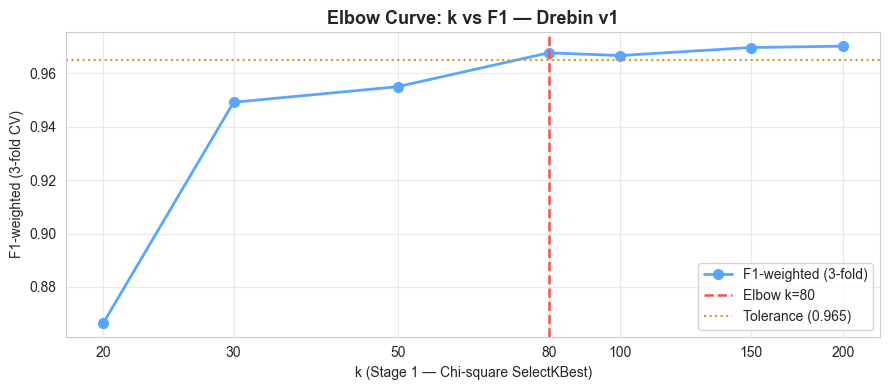


Running Two-Stage Feature Selection (K_STAGE1=80, corr_threshold=0.95)...
[Stage 1] Chi2 SelectKBest: 80 features (k=80)
[Stage 2] Correlation filter (|r|>0.95): 76 features
Done in 0.0s
Final features: 76 / 215
X_sel shape: (15036, 76)


In [4]:
# ── K vs F1 Elbow Analysis ───────────────────────────────────────────────────
# Drebin: 215 features → range k nho hon MalDroid2020
K_CANDIDATES = [20, 30, 50, 80, 100, 150, 200]
K_CANDIDATES = [k for k in K_CANDIDATES if k <= X.shape[1]]
TOLERANCE    = 0.005  # nguong: F1 trong 0.5% cua peak → la 'du tot'

elbow_clf = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

k_scores = []
print('Elbow Analysis — k vs F1 (3-fold CV, RF fast):')
for k in K_CANDIDATES:
    sel = SelectKBest(chi2, k=min(k, X.shape[1]))
    X_k = sel.fit_transform(X, y)
    f1_k = cross_val_score(elbow_clf, X_k, y, cv=skf3, scoring='f1_weighted', n_jobs=-1).mean()
    k_scores.append(f1_k)
    print(f'  k={k:4d}  F1={f1_k:.4f}')

# Tim elbow: k nho nhat ma F1 >= peak - tolerance
peak_f1 = max(k_scores)
elbow_k = K_CANDIDATES[next(i for i, s in enumerate(k_scores) if s >= peak_f1 - TOLERANCE)]
print(f'\nPeak F1 = {peak_f1:.4f} | Elbow k = {elbow_k}')

# Ve Elbow Curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_CANDIDATES, k_scores, 'o-', color='#58a6ff', linewidth=2, markersize=7, label='F1-weighted (3-fold)')
ax.axvline(x=elbow_k, color='#f85149', linestyle='--', linewidth=1.8, label=f'Elbow k={elbow_k}')
ax.axhline(y=peak_f1 - TOLERANCE, color='#d29922', linestyle=':', linewidth=1.5, label=f'Tolerance ({peak_f1-TOLERANCE:.3f})')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(K_CANDIDATES)
ax.set_xticklabels(K_CANDIDATES)
ax.set_xlabel('k (Stage 1 — Chi-square SelectKBest)')
ax.set_ylabel('F1-weighted (3-fold CV)')
ax.set_title('Elbow Curve: k vs F1 — Drebin v1', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / '16_drebin_elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chay Two-Stage voi elbow_k ───────────────────────────────────────────────
K_STAGE1    = elbow_k
CORR_THRESH = 0.95
print(f'\nRunning Two-Stage Feature Selection (K_STAGE1={K_STAGE1}, corr_threshold={CORR_THRESH})...')
t0 = time.time()
selected_idx, selected_features, chi2_scores_all, chi2_pvalues_all = two_stage_feature_selection(
    X, y, feature_names, k_stage1=K_STAGE1, corr_threshold=CORR_THRESH
)
X_sel = X[:, selected_idx]
print(f'Done in {time.time()-t0:.1f}s')
print(f'Final features: {len(selected_features)} / {len(feature_names)}')
print(f'X_sel shape: {X_sel.shape}')

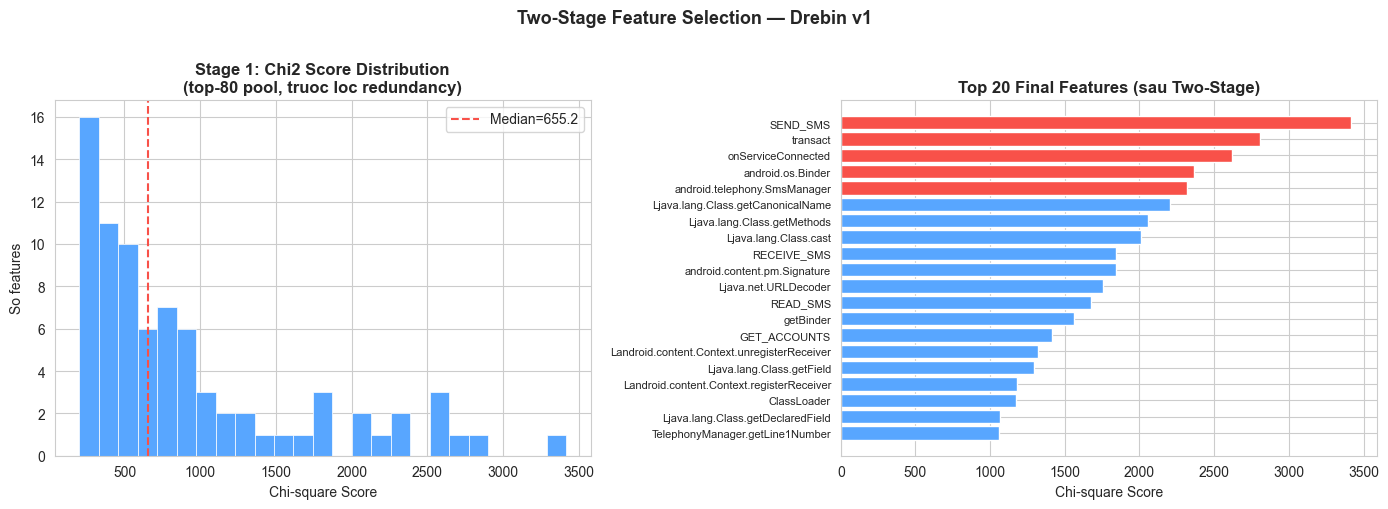

Feature reduction: 215 -> 76 (35.3%)


In [5]:
# Visualize Two-Stage Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Chi2 score distribution (Stage 1 pool)
stage1_sel = SelectKBest(chi2, k=min(K_STAGE1, X.shape[1]))
stage1_sel.fit(X, y)
stage1_idx_vis = np.where(stage1_sel.get_support())[0]
stage1_scores  = chi2_scores_all[stage1_idx_vis]
axes[0].hist(stage1_scores, bins=25, color='#58a6ff', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Chi-square Score')
axes[0].set_ylabel('So features')
axes[0].set_title(f'Stage 1: Chi2 Score Distribution\n(top-{K_STAGE1} pool, truoc loc redundancy)', fontweight='bold')
axes[0].axvline(np.median(stage1_scores), color='#f85149', linestyle='--', label=f'Median={np.median(stage1_scores):.1f}')
axes[0].legend()

# Right: Top 20 final features by Chi2 score
final_scores = [(feature_names[i], chi2_scores_all[i]) for i in selected_idx]
final_scores.sort(key=lambda x: x[1], reverse=True)
TOP_N = min(20, len(final_scores))
top_names  = [s[0] for s in final_scores[:TOP_N]]
top_scores = [s[1] for s in final_scores[:TOP_N]]
colors = ['#f85149' if i < 5 else '#58a6ff' for i in range(TOP_N)]
axes[1].barh(range(TOP_N), top_scores[::-1], color=colors[::-1])
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(top_names[::-1], fontsize=8)
axes[1].set_xlabel('Chi-square Score')
axes[1].set_title(f'Top {TOP_N} Final Features (sau Two-Stage)', fontweight='bold')

plt.suptitle('Two-Stage Feature Selection — Drebin v1', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '17_drebin_feature_selection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Feature reduction: {len(feature_names)} -> {len(selected_features)} ({len(selected_features)/len(feature_names)*100:.1f}%)')

## 4. Model Training — Stratified 5-Fold Cross-Validation

In [6]:
def evaluate(y_true, y_pred, y_proba=None):
    metrics = {
        'accuracy':  float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'recall':    float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'f1':        float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'mcc':       float(matthews_corrcoef(y_true, y_pred)),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    if y_proba is not None:
        try:
            if y_proba.ndim == 2 and y_proba.shape[1] == 2:
                metrics['roc_auc'] = float(roc_auc_score(y_true, y_proba[:, 1]))
            else:
                metrics['roc_auc'] = float(roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted'))
        except Exception:
            pass
    return metrics

print('evaluate() defined.')

evaluate() defined.


In [7]:
# XGBoost check
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print('[OK] XGBoost available')
except ImportError:
    XGB_AVAILABLE = False
    print('[WARN] XGBoost khong co san. Cai bang: uv pip install xgboost')

CLASSIFIERS = {
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    ),
    'SVM (Linear)': (
        SVC(class_weight='balanced', probability=True, kernel='linear', random_state=42),
        {'C': [0.3, 1, 3, 10]},
    ),
    'k-NN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 11], 'metric': ['euclidean', 'manhattan']},
    ),
    'Naive Bayes': (GaussianNB(), {}),
    'MLP (Neural Net)': (
        MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                      early_stopping=True, validation_fraction=0.1, random_state=42),
        {'alpha': [1e-4, 1e-3, 1e-2], 'learning_rate_init': [0.001, 0.01]},
    ),
}
if XGB_AVAILABLE:
    CLASSIFIERS['XGBoost'] = (
        XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1]},
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = {}

for name, (clf_base, param_grid) in CLASSIFIERS.items():
    print(f'\n{chr(8212)*50}')
    print(f'  Training: {name}')
    print(f'{chr(8212)*50}')
    t0 = time.time()
    fold_preds, fold_true, fold_probas, fold_scores = [], [], [], []
    n_iter   = 3 if 'SVM' in name else 5
    cv_inner = 2 if 'SVM' in name else 3

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):
        X_tr, X_val = X_sel[tr_idx], X_sel[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        if param_grid:
            search = RandomizedSearchCV(clf_base, param_grid, n_iter=n_iter, cv=cv_inner,
                                        scoring='f1_weighted', random_state=42, n_jobs=-1)
            search.fit(X_tr, y_tr)
            clf_fold = search.best_estimator_
        else:
            clf_fold = clf_base.__class__(**clf_base.get_params())
            clf_fold.fit(X_tr, y_tr)
        y_pred = clf_fold.predict(X_val)
        fold_preds.extend(y_pred)
        fold_true.extend(y_val)
        try:
            fold_probas.extend(clf_fold.predict_proba(X_val))
        except Exception:
            pass
        fm = evaluate(y_val, y_pred)
        fold_scores.append(fm)
        print(f'  Fold {fold} — acc={fm["accuracy"]:.4f}  f1={fm["f1"]:.4f}  mcc={fm["mcc"]:.4f}')

    probas_arr = np.array(fold_probas) if fold_probas else None
    overall = evaluate(np.array(fold_true), np.array(fold_preds), probas_arr)
    avg = {k: float(np.mean([s[k] for s in fold_scores if k in s]))
           for k in ['accuracy', 'precision', 'recall', 'f1', 'mcc']}
    avg['roc_auc']          = overall.get('roc_auc')
    avg['confusion_matrix'] = confusion_matrix(fold_true, fold_preds).tolist()
    avg['train_time_s']     = round(time.time() - t0, 1)
    all_results[name] = avg
    print(f'  AVG — acc={avg["accuracy"]:.4f}  f1={avg["f1"]:.4f}  '
          f'mcc={avg["mcc"]:.4f}  auc={avg.get("roc_auc","N/A")}  ({avg["train_time_s"]}s)')

print(f'\n[DONE] Tong {len(all_results)} models da train.')

[OK] XGBoost available

——————————————————————————————————————————————————
  Training: Random Forest
——————————————————————————————————————————————————
  Fold 1 — acc=0.9830  f1=0.9830  mcc=0.9636
  Fold 2 — acc=0.9844  f1=0.9843  mcc=0.9664
  Fold 3 — acc=0.9864  f1=0.9864  mcc=0.9707
  Fold 4 — acc=0.9781  f1=0.9780  mcc=0.9529
  Fold 5 — acc=0.9820  f1=0.9820  mcc=0.9615
  AVG — acc=0.9828  f1=0.9827  mcc=0.9630  auc=0.9967558519668014  (11.9s)

——————————————————————————————————————————————————
  Training: SVM (Linear)
——————————————————————————————————————————————————
  Fold 1 — acc=0.9658  f1=0.9657  mcc=0.9264
  Fold 2 — acc=0.9618  f1=0.9618  mcc=0.9180
  Fold 3 — acc=0.9647  f1=0.9648  mcc=0.9248
  Fold 4 — acc=0.9618  f1=0.9618  mcc=0.9179
  Fold 5 — acc=0.9638  f1=0.9637  mcc=0.9221
  AVG — acc=0.9636  f1=0.9636  mcc=0.9218  auc=0.9910695536015257  (80.4s)

——————————————————————————————————————————————————
  Training: k-NN
——————————————————————————————————————————————————


## 5. So sánh kết quả — Bảng tổng hợp

In [8]:
metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'train_time_s']
df_results = pd.DataFrame(
    {name: {k: res[k] for k in metrics_cols if k in res}
     for name, res in all_results.items()}
).T

df_display = df_results.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc']:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(lambda x: f'{float(x):.4f}' if pd.notna(x) else chr(8212))
df_display['train_time_s'] = df_display['train_time_s'].apply(lambda x: f'{float(x):.1f}s')

print('=' * 95)
print('  Ket qua Stratified 5-Fold CV — Drebin v1 (Binary Classification)')
print('=' * 95)
print(df_display.to_string())
print('=' * 95)

best_model_name = df_results['f1'].astype(float).idxmax()
best_f1 = float(df_results.loc[best_model_name, 'f1'])
print(f'\nBest model: {best_model_name}  (F1 = {best_f1:.4f})')

  Ket qua Stratified 5-Fold CV — Drebin v1 (Binary Classification)
                 accuracy precision  recall      f1     mcc roc_auc train_time_s
Random Forest      0.9828    0.9828  0.9828  0.9827  0.9630  0.9968        11.9s
SVM (Linear)       0.9636    0.9636  0.9636  0.9636  0.9218  0.9911        80.4s
k-NN               0.9269    0.9359  0.9269  0.9278  0.8555  0.9522        14.3s
Naive Bayes        0.7819    0.8502  0.7819  0.7845  0.6267  0.8599         0.1s
MLP (Neural Net)   0.9826    0.9827  0.9826  0.9826  0.9627  0.9961        26.4s
XGBoost            0.9794    0.9795  0.9794  0.9794  0.9559  0.9967         4.3s

Best model: Random Forest  (F1 = 0.9827)


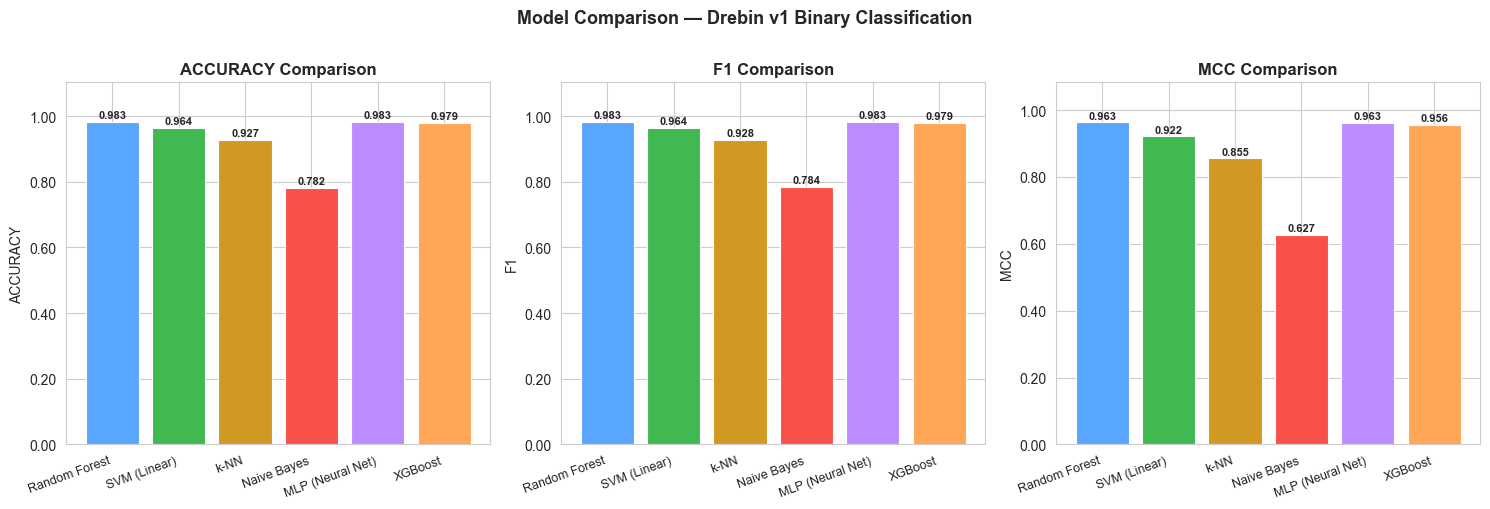

In [9]:
plot_metrics = ['accuracy', 'f1', 'mcc']
df_plot = df_results[plot_metrics].astype(float)
model_names = df_plot.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = ['#58a6ff', '#3fb950', '#d29922', '#f85149', '#bc8cff', '#ffa657']

for ax, metric in zip(axes, plot_metrics):
    vals = df_plot[metric].values
    bars = ax.bar(range(len(model_names)), vals,
                  color=bar_colors[:len(model_names)], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} Comparison', fontweight='bold')
    ax.set_ylim(0, min(1.15, vals.max() + 0.12))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.suptitle('Model Comparison — Drebin v1 Binary Classification', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '17_drebin_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion Matrix — Best Model

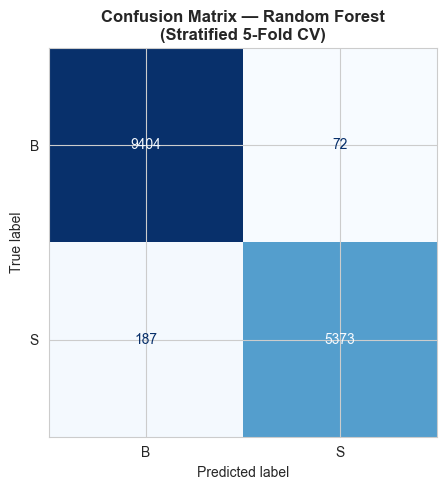

In [10]:
best_cm = np.array(all_results[best_model_name]['confusion_matrix'])
class_labels = [str(c) for c in le.classes_]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=class_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Confusion Matrix — {best_model_name}\n(Stratified 5-Fold CV)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '18_drebin_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Retrain & Lưu Artifacts

In [11]:
import json, datetime

# ── Retrain ALL models on full data & save individually ──────────────────────
all_final_models = {}

for name, (clf_base, param_grid) in CLASSIFIERS.items():
    print(f'\nRetrain {name} on full data...')
    n_iter_f   = 3 if 'SVM' in name else 5
    cv_inner_f = 2 if 'SVM' in name else 3

    if param_grid:
        search = RandomizedSearchCV(
            clf_base, param_grid, n_iter=n_iter_f, cv=cv_inner_f,
            scoring='f1_weighted', random_state=42, n_jobs=-1
        )
        search.fit(X_sel, y)
        clf_full = search.best_estimator_
    else:
        clf_full = clf_base.__class__(**clf_base.get_params())
        clf_full.fit(X_sel, y)

    all_final_models[name] = clf_full
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    joblib.dump(clf_full, OUT_DIR / f'model_{safe_name}_drebin.pkl')

    # metrics.json per model
    res = all_results.get(name, {})
    metrics_out = {
        'algorithm': name,
        'accuracy':            round(float(res.get('accuracy', 0)), 4),
        'f1_weighted':         round(float(res.get('f1', 0)), 4),
        'precision_weighted':  round(float(res.get('precision', 0)), 4),
        'recall_weighted':     round(float(res.get('recall', 0)), 4),
        'mcc':                 round(float(res.get('mcc', 0)), 4),
        'roc_auc':             round(float(res.get('roc_auc') or 0), 4),
        'train_time_s':        res.get('train_time_s', 0),
    }
    with open(OUT_DIR / f'metrics_{safe_name}_drebin.json', 'w', encoding='utf-8') as mf:
        json.dump(metrics_out, mf, indent=2)

    marker = ' <- BEST' if name == best_model_name else ''
    print(f'  Saved model_{safe_name}_drebin.pkl  '
          f'(f1={metrics_out["f1_weighted"]:.4f}){marker}')

# model_best_drebin.pkl = alias cho best
joblib.dump(all_final_models[best_model_name], OUT_DIR / 'model_best_drebin.pkl')

# ── Shared artifacts ──────────────────────────────────────────────────────────
with open(OUT_DIR / 'selected_features_drebin.pkl', 'wb') as f:
    pickle.dump(selected_features, f)
with open(OUT_DIR / 'all_features_drebin.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
joblib.dump(scaler, OUT_DIR / 'scaler_drebin.pkl')
with open(OUT_DIR / 'label_encoder_drebin.pkl', 'wb') as f:
    pickle.dump(le, f)
df_results.to_csv(OUT_DIR / 'cv_results_drebin.csv')

# ── pipeline_summary_drebin.json ─────────────────────────────────────────────
pipeline_summary = {
    'dataset': 'Drebin v1',
    'task': 'binary',
    'label_classes': [str(c) for c in le.classes_],
    'n_samples': int(X_sel.shape[0]),
    'n_features_original': int(len(feature_names)),
    'n_features_selected': int(len(selected_features)),
    'feature_selection_method': 'Two-Stage (Chi-square + Pearson Correlation Filter)',
    'best_model': best_model_name,
    'best_f1_weighted': round(float(best_f1), 4),
    'cv_folds': 5,
    'model_results': {
        name: {
            'accuracy':           round(float(res.get('accuracy', 0)), 4),
            'f1_weighted':        round(float(res.get('f1', 0)), 4),
            'precision_weighted': round(float(res.get('precision', 0)), 4),
            'recall_weighted':    round(float(res.get('recall', 0)), 4),
            'mcc':                round(float(res.get('mcc', 0)), 4),
            'roc_auc':            round(float(res.get('roc_auc') or 0), 4),
        }
        for name, res in all_results.items()
    },
    'saved_at': datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
}
with open(OUT_DIR / 'pipeline_summary_drebin.json', 'w', encoding='utf-8') as f:
    json.dump(pipeline_summary, f, indent=2, ensure_ascii=False)

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('  Artifacts saved -> notebooks/artifacts/drebin/')
print('=' * 60)
for name in CLASSIFIERS:
    safe = name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    f1_val = round(all_results.get(name, {}).get('f1', 0), 4)
    marker = ' <- BEST' if name == best_model_name else ''
    print(f'  model_{safe}_drebin.pkl  (f1={f1_val}){marker}')
print(f'  model_best_drebin.pkl         <- alias for {best_model_name}')
print(f'  selected_features_drebin.pkl  <- {len(selected_features)} features')
print(f'  all_features_drebin.pkl       <- {len(feature_names)} features (full schema)')
print(f'  scaler_drebin.pkl, label_encoder_drebin.pkl')
print(f'  cv_results_drebin.csv, pipeline_summary_drebin.json')
print('=' * 60)
print(f'\n  Best model  : {best_model_name}')
print(f'  F1-weighted : {best_f1:.4f}')
print(f'  Features    : {len(selected_features)} selected from {len(feature_names)}')


Retrain Random Forest on full data...
  Saved model_Random_Forest_drebin.pkl  (f1=0.9827) <- BEST

Retrain SVM (Linear) on full data...
  Saved model_SVM_Linear_drebin.pkl  (f1=0.9636)

Retrain k-NN on full data...
  Saved model_k-NN_drebin.pkl  (f1=0.9278)

Retrain Naive Bayes on full data...
  Saved model_Naive_Bayes_drebin.pkl  (f1=0.7845)

Retrain MLP (Neural Net) on full data...
  Saved model_MLP_Neural_Net_drebin.pkl  (f1=0.9826)

Retrain XGBoost on full data...
  Saved model_XGBoost_drebin.pkl  (f1=0.9794)

  Artifacts saved -> notebooks/artifacts/drebin/
  model_Random_Forest_drebin.pkl  (f1=0.9827) <- BEST
  model_SVM_Linear_drebin.pkl  (f1=0.9636)
  model_k-NN_drebin.pkl  (f1=0.9278)
  model_Naive_Bayes_drebin.pkl  (f1=0.7845)
  model_MLP_Neural_Net_drebin.pkl  (f1=0.9826)
  model_XGBoost_drebin.pkl  (f1=0.9794)
  model_best_drebin.pkl         <- alias for Random Forest
  selected_features_drebin.pkl  <- 76 features
  all_features_drebin.pkl       <- 215 features (full schem